# Bulk RNA-seq mapping with STAR

This notebook demonstrates an end-to-end bulk RNA-seq workflow in **OmicVerse**, starting from raw reads and ending with differential expression (DE) results and visualization.

**Workflow**
1. Import OmicVerse and set plotting style  
2. Download paired-end FASTQ from SRA  
3. Quality control and trimming (fastp)  
4. Download reference genome and annotation (Ensembl GRCh38 release 115)  
5. Align reads with STAR  
6. Gene-level quantification (featureCounts)  
7. Differential expression and visualization (pyDEG)

> **Note**  
> The full tutorial series can continue from DE into functional enrichment and PPI network analysis. This notebook focuses on the core preprocessing + DE workflow.

**Requirements**
- External tools: `fasterq-dump` (SRA Toolkit), `fastp`, `STAR`, and `featureCounts` (Subread).  
- Storage: FASTQ + alignment outputs can be large; ensure adequate disk space.  
- Memory: STAR genome indexing/alignment can require **high RAM** (see the STAR step below).

---

## 1) Import OmicVerse

We first import OmicVerse and configure a consistent plotting style. `ov.style(font_path='Arial')` will download/install the font if it is not available locally.



In [1]:
import omicverse as ov
ov.style(font_path='Arial')

🔬 Starting plot initialization...
Arial font downloaded successfully to: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.9rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 2) Download FASTQ data from SRA

We download **4 paired-end samples** as a lightweight example:
- Disease group: `SRR12544419`, `SRR12544421`  
- Healthy group: `SRR12544529`, `SRR12544531`

▲ **CRITICAL**  
`ov.alignment.fqdump()` will **prioritize using pre-downloaded SRA files** found in `sra_dir`. If not found, it will download the data and convert it into FASTQ according to `library_layout`.



In [5]:
fq_data = ov.alignment.fqdump(
    # Download 4 samples as example
    sra_ids=['SRR12544419','SRR12544421',#disease group
       'SRR12544529','SRR12544531',# healthy group
    ],
    sra_dir = "./data", 
    temp_dir = './data/tmp',
    output_dir="./data/fqdata",
    library_layout="paired", # pair-end data
)
print(fq_data)

>> /home/groups/xiaojie/steorra/env/omicverse/bin/fasterq-dump SRR12544529 -O data/fqdata/SRR12544529 -e 8 --mem 4G --split-files --progress -t data/tmp/SRR12544529
>> /home/groups/xiaojie/steorra/env/omicverse/bin/fasterq-dump SRR12544421 -O data/fqdata/SRR12544421 -e 8 --mem 4G --split-files --progress -t data/tmp/SRR12544421
>> /home/groups/xiaojie/steorra/env/omicverse/bin/fasterq-dump SRR12544531 -O data/fqdata/SRR12544531 -e 8 --mem 4G --split-files --progress -t data/tmp/SRR12544531
>> /home/groups/xiaojie/steorra/env/omicverse/bin/fasterq-dump SRR12544419 -O data/fqdata/SRR12544419 -e 8 --mem 4G --split-files --progress -t data/tmp/SRR12544419
join   :|  0.00% 0.01% 0.02% 0.03% 0.04% 0.05% 0.06% 0.07% 0.08% 0.09% 0.10% 0.11% 0.12% 0.13% 0.14% 0.15% 0.16% 0.17% 0.18% 0.19% 0.20% 0.21% 0.22% 0.23% 0.24% 0.25% 0.26% 0.27% 0.28% 0.29% 0.30% 0.31% 0.32% 0.33% 0.34% 0.35% 0.36% 0.37% 0.38% 0.39% 0.40% 0.41% 0.42% 0.43% 0.44% 0.45% 0.46% 0.47% 0.48% 0.49% 0.50% 0.51% 0.52% 0.53% 0.54%

## 3) Quality control and trimming (fastp)

We run `fastp` on each sample and save the cleaned FASTQ files plus QC reports.

**Outputs**
- Clean reads: `./result/fqdata/<sample>/*_clean_*.fastq`
- Reports: `*.fastp.json` and `*.fastp.html`

⏱️ Runtime: typically **~tens of seconds** for this small example, depending on compute and disk.



In [6]:
from operator import itemgetter

qc_result = ov.alignment.fastp(
    samples=list(map(itemgetter("srr", "fq1", "fq2"), fq_data)),
    output_dir = './result/fqdata')
print(qc_result)

>> /home/users/steorra/miniforge3/bin/fastp -i data/fqdata/SRR12544421/SRR12544421_1.fastq -o result/fqdata/SRR12544421/SRR12544421_clean_1.fastq -w 8 -j result/fqdata/SRR12544421/SRR12544421.fastp.json -h result/fqdata/SRR12544421/SRR12544421.fastp.html -I data/fqdata/SRR12544421/SRR12544421_2.fastq -O result/fqdata/SRR12544421/SRR12544421_clean_2.fastq --detect_adapter_for_pe
>> /home/users/steorra/miniforge3/bin/fastp -i data/fqdata/SRR12544419/SRR12544419_1.fastq -o result/fqdata/SRR12544419/SRR12544419_clean_1.fastq -w 8 -j result/fqdata/SRR12544419/SRR12544419.fastp.json -h result/fqdata/SRR12544419/SRR12544419.fastp.html -I data/fqdata/SRR12544419/SRR12544419_2.fastq -O result/fqdata/SRR12544419/SRR12544419_clean_2.fastq --detect_adapter_for_pe
>> /home/users/steorra/miniforge3/bin/fastp -i data/fqdata/SRR12544531/SRR12544531_1.fastq -o result/fqdata/SRR12544531/SRR12544531_clean_1.fastq -w 8 -j result/fqdata/SRR12544531/SRR12544531.fastp.json -h result/fqdata/SRR12544531/SRR125

## 4) Download reference genome and gene annotation (Ensembl)

We download:
- GRCh38 primary assembly FASTA
- GRCh38 GTF annotation (release 115)

Tip: keep these files cached locally to avoid repeated downloads.



In [9]:
ov.datasets.download_data('ftp://ftp.ensembl.org/pub/release-115/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz',dir='./genomes')
ov.datasets.download_data('ftp://ftp.ensembl.org/pub/release-115/gtf/homo_sapiens/Homo_sapiens.GRCh38.115.gtf.gz',dir='./genomes')

🔍 Downloading data to ./genomes/Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz
⚠️ File ./genomes/Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz already exists
🔍 Downloading data to ./genomes/Homo_sapiens.GRCh38.115.gtf.gz


Downloading: 100%|█████████▉| 104M/104M [00:18<00:00, 5.64MB/s] 

✅ Download completed


'./genomes/Homo_sapiens.GRCh38.115.gtf.gz'

## 5) QC results (cached example structure)

The following cell provides an **example `qc_result` structure** (paths to cleaned reads + reports).  
This is useful for quickly continuing the tutorial without rerunning QC.

If you re-run the QC step above on your machine, you can keep using the `qc_result` produced by `ov.alignment.fastp()`.



In [3]:
qc_result=[
{'sample': 'SRR12544419', 
 'clean1': 'result/fqdata/SRR12544419/SRR12544419_clean_1.fastq', 
 'clean2': 'result/fqdata/SRR12544419/SRR12544419_clean_2.fastq', 
 'json': 'result/fqdata/SRR12544419/SRR12544419.fastp.json', 
 'html': 'result/fqdata/SRR12544419/SRR12544419.fastp.html'}, 
{'sample': 'SRR12544421', 
 'clean1': 'result/fqdata/SRR12544421/SRR12544421_clean_1.fastq', 
 'clean2': 'result/fqdata/SRR12544421/SRR12544421_clean_2.fastq', 
 'json': 'result/fqdata/SRR12544421/SRR12544421.fastp.json', 
 'html': 'result/fqdata/SRR12544421/SRR12544421.fastp.html'}, 
{'sample': 'SRR12544529', 
 'clean1': 'result/fqdata/SRR12544529/SRR12544529_clean_1.fastq', 
 'clean2': 'result/fqdata/SRR12544529/SRR12544529_clean_2.fastq', 
 'json': 'result/fqdata/SRR12544529/SRR12544529.fastp.json', 
 'html': 'result/fqdata/SRR12544529/SRR12544529.fastp.html'}, 
{'sample': 'SRR12544531', 
 'clean1': 'result/fqdata/SRR12544531/SRR12544531_clean_1.fastq', 
 'clean2': 'result/fqdata/SRR12544531/SRR12544531_clean_2.fastq', 
 'json': 'result/fqdata/SRR12544531/SRR12544531.fastp.json', 
 'html': 'result/fqdata/SRR12544531/SRR12544531.fastp.html'}
]

## 6) Prepare STAR input list

STAR expects a list of `(sample, read1, read2)` tuples.  
We construct that list from `qc_result`.



In [5]:
from operator import itemgetter
list(map(itemgetter("sample", "clean1", "clean2"), qc_result))

[('SRR12544419',
  'result/fqdata/SRR12544419/SRR12544419_clean_1.fastq',
  'result/fqdata/SRR12544419/SRR12544419_clean_2.fastq'),
 ('SRR12544421',
  'result/fqdata/SRR12544421/SRR12544421_clean_1.fastq',
  'result/fqdata/SRR12544421/SRR12544421_clean_2.fastq'),
 ('SRR12544529',
  'result/fqdata/SRR12544529/SRR12544529_clean_1.fastq',
  'result/fqdata/SRR12544529/SRR12544529_clean_2.fastq'),
 ('SRR12544531',
  'result/fqdata/SRR12544531/SRR12544531_clean_1.fastq',
  'result/fqdata/SRR12544531/SRR12544531_clean_2.fastq')]

## 7) Align reads to the reference genome with STAR

We align cleaned reads to GRCh38 using STAR.

▲ **CRITICAL**
- The **first run** will create the STAR genome index (genome initialization), which can take **~20 minutes** depending on hardware and I/O.
- STAR is memory intensive; the comment in the code notes that **high RAM is required**.

**Outputs**
- Sorted BAM: `./result/alignment/<sample>/Aligned.sortedByCoord.out.bam` (path may vary by STAR settings)



In [ ]:
align_result = ov.alignment.STAR(
    samples=list(map(itemgetter("sample", "clean1", "clean2"), qc_result)),
    genome_dir='genomes',
    genome_fasta_files="genomes/Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz",
    gtf='genomes/Homo_sapiens.GRCh38.115.gtf.gz',
    sjdb_overhang=100,
    output_dir = './result/alignment',
    jobs=8 # 1 job require at least 48GB memory
)
print(align_result)

>> /home/groups/xiaojie/steorra/env/omicverse/bin/STAR --runMode genomeGenerate --genomeDir genomes --genomeFastaFiles genomes/Homo_sapiens.GRCh38.dna.primary_assembly.fa --runThreadN 8 --sjdbGTFfile genomes/Homo_sapiens.GRCh38.115.gtf --sjdbGTFfeatureExon exon --sjdbOverhang 100
	/home/groups/xiaojie/steorra/env/omicverse/bin/STAR-avx2 --runMode genomeGenerate --genomeDir genomes --genomeFastaFiles genomes/Homo_sapiens.GRCh38.dna.primary_assembly.fa --runThreadN 8 --sjdbGTFfile genomes/Homo_sapiens.GRCh38.115.gtf --sjdbGTFfeatureExon exon --sjdbOverhang 100
	STAR version: 2.7.11b   compiled: 2025-07-24T03:06:21+0000 :/opt/conda/conda-bld/star_1753326220084/work/source
Feb 06 17:41:00 ..... started STAR run
Feb 06 17:41:00 ... starting to generate Genome files
Feb 06 17:41:45 ..... processing annotations GTF


## 8) Alignment results (cached example structure)

The next cell provides an example `align_result` list (sample → BAM path).  
This allows you to proceed to quantification even if you skip re-running STAR in this tutorial environment.



In [6]:
align_result=[
    {'sample':'SRR12544419',
    'bam':'result/alignment/SRR12544419/Aligned.sortedByCoord.out.bam'},
    {'sample':'SRR12544421',
    'bam':'result/alignment/SRR12544421/Aligned.sortedByCoord.out.bam'},
    {'sample':'SRR12544529',
    'bam':'result/alignment/SRR12544529/Aligned.sortedByCoord.out.bam'},
    {'sample':'SRR12544531',
    'bam':'result/alignment/SRR12544531/Aligned.sortedByCoord.out.bam'},
]

## 9) Gene-level quantification with featureCounts

We quantify reads to genes using `featureCounts` (via OmicVerse wrapper), generating a raw count matrix.

**Output**
- `count_result`: a pandas DataFrame with **genes × samples** (raw counts), optionally mapped to gene symbols when `gene_mapping=True`.



In [7]:
count_result = ov.alignment.featureCount(
    bam_items=list(map(itemgetter("sample", "bam"), align_result)),
    gtf='genomes/Homo_sapiens.GRCh38.115.gtf.gz',
    output_dir = './result/count',
    gene_mapping=True,
    gene_name_field="gene_name",
    jobs=8
)
print(count_result)

                 SRR12544419  SRR12544421  SRR12544529  SRR12544531
gene_id                                                            
PRDM16                     2            0            0            0
ENSG00000284616            0            0            0            0
ENSG00000260972            0            0            0            0
EEF1DP6                    0            0            0            0
LINC01646                  0            0            0            0
...                      ...          ...          ...          ...
ENSG00000307722            0            0            0            0
ENSG00000310401            0            0            0            0
ENSG00000302039            0            2           24            0
ENSG00000309831            2            6            0            1
ENSG00000309258            0            0            0            0

[78899 rows x 4 columns]


In [8]:
count_result.head()

,SRR12544419,SRR12544421,SRR12544529,SRR12544531
gene_id,,,,
PRDM16,2,0,0,0
ENSG00000284616,0,0,0,0
ENSG00000260972,0,0,0,0
EEF1DP6,0,0,0,0
LINC01646,0,0,0,0


## 10) Create a DE object (pyDEG)

We build an OmicVerse `pyDEG` object from the count matrix for downstream DE analysis and plotting.



In [9]:
data = count_result
dds=ov.bulk.pyDEG(data)

## 11) Basic cleanup

We remove duplicated gene entries (if any).  
Downstream steps assume the index uniquely identifies genes.



In [10]:
dds.drop_duplicates_index()
print('... drop_duplicates_index success')

... drop_duplicates_index success


## 12) Differential expression (DE)

Define treatment/control sample lists and run DE. OmicVerse supports multiple DE methods, including:
- `ttest`
- `edgepy`
- `limma`
- `DEseq2`

▲ **CRITICAL** (DESeq2)
If you use `DEseq2`, ensure the input matrix is **raw integer counts**, and avoid applying external normalization beforehand (DESeq2 estimates size factors internally).



In [11]:
disease_groups = ['SRR12544419','SRR12544421']
healthy_groups = ['SRR12544529','SRR12544531']
result=dds.deg_analysis(disease_groups,healthy_groups,method='DEseq2')

⚙️ You are using DEseq2 method for differential expression analysis.
⏰ Start to create DeseqDataSet...


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 1.96 seconds.

Fitting dispersion trend curve...
... done in 0.50 seconds.

Fitting MAP dispersions...


logres_prior=1.028669461109852, sigma_prior=0.25


... done in 2.49 seconds.

Fitting LFCs...
... done in 1.89 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: condition Treatment vs Control
                      baseMean  log2FoldChange     lfcSE      stat  \
gene_id                                                              
S100A9           551268.969994       -1.996395  0.567251 -3.519423   
S100A8           470875.870644       -1.860539  0.580843 -3.203169   
MT-RNR2          379360.147119       -1.073334  0.462907 -2.318684   
HBB              255919.879002       -3.412494  0.550731 -6.196301   
B2M              224562.599264       -0.016376  0.477808 -0.034274   
...                        ...             ...       ...       ...   
RN7SKP39              0.000000             NaN       NaN       NaN   
RNU4ATAC6P            0.000000             NaN       NaN       NaN   
TPRKBP1               0.000000             NaN       NaN       NaN   
RNU7-107P             0.000000             NaN       NaN       NaN   
ENSG00000271220       0.000000             NaN       NaN       NaN   

                    

... done in 88.55 seconds.



## 13) Filter low-expression genes

A simple filter can reduce noise and improve interpretability.



In [12]:
dds.result=dds.result.loc[dds.result['log2(BaseMean)']>1]

## 14) Set thresholds and inspect top DE genes

We set fold-change / p-value thresholds and extract the **Top 10** significant DEGs for visualization.



In [13]:
import matplotlib.pyplot as plt
# fc_treshold = -1 means automatically calculate
dds.foldchange_set(fc_threshold=1,pval_threshold=0.05,logp_max=20)
res = dds.result.copy()
sig = res[(res["qvalue"] < 0.05) & (res["log2FC"].abs() > 0.5)&(res["log2(BaseMean)"]<20)].sort_values(["qvalue","log2FC"], ascending=[True, False])

gene_list = sig[["log2FC","qvalue"]].head(10).index.to_list() # Top10 significant DEGs
print("Top10 significant DEGs:",gene_list)

... Fold change threshold: 1
Top10 significant DEGs: ['RPH3A', 'MYOM2', 'HBA2', 'EGR2', 'HBB', 'ASPM', 'HLA-V|ENSG00000290710', 'TOP2A', 'ALAS2', 'ENSG00000287255']


## 15) Visualize DE results

We generate:
- Volcano plot summarizing DE results
- Boxplots for selected genes (Top hits)

Tip: `dds.plot_boxplot()` is helpful for sanity-checking individual gene behavior across groups.



🌋 Volcano Plot Analysis:
   Total genes: 25211
   ↗️  Upregulated genes: 88
   ↘️  Downregulated genes: 123
   ➡️  Non-significant genes: 25000
   🎯 Total significant genes: 211
   log2FC range: -14.16 to 9.33
   qvalue range: 9.31e-17 to 1.00e+00

⚙️  Current Function Parameters:
   Data columns: pval_name='qvalue', fc_name='log2FC'
   Thresholds: pval_threshold=0.05, fc_max=1, fc_min=-1
   Plot size: figsize=(5, 5)
   Gene labels: plot_genes_num=8, plot_genes_fontsize=12
   Custom genes: None (auto-select top genes)

💡 Parameter Optimization Suggestions:
   ▶ Wide fold change range detected:
     Current: fc_max=1, fc_min=-1
     Suggested: fc_max=2.6, fc_min=-2.8

   📋 Copy-paste ready function call:
   ov.pl.volcano(result, fc_max=2.6, fc_min=-2.8)
────────────────────────────────────────────────────────────


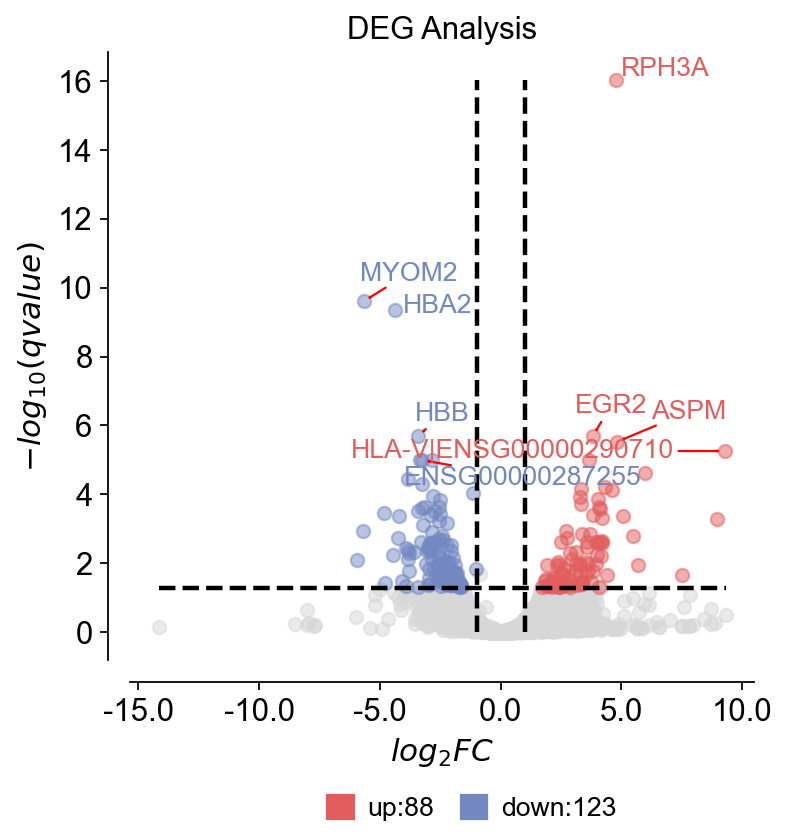

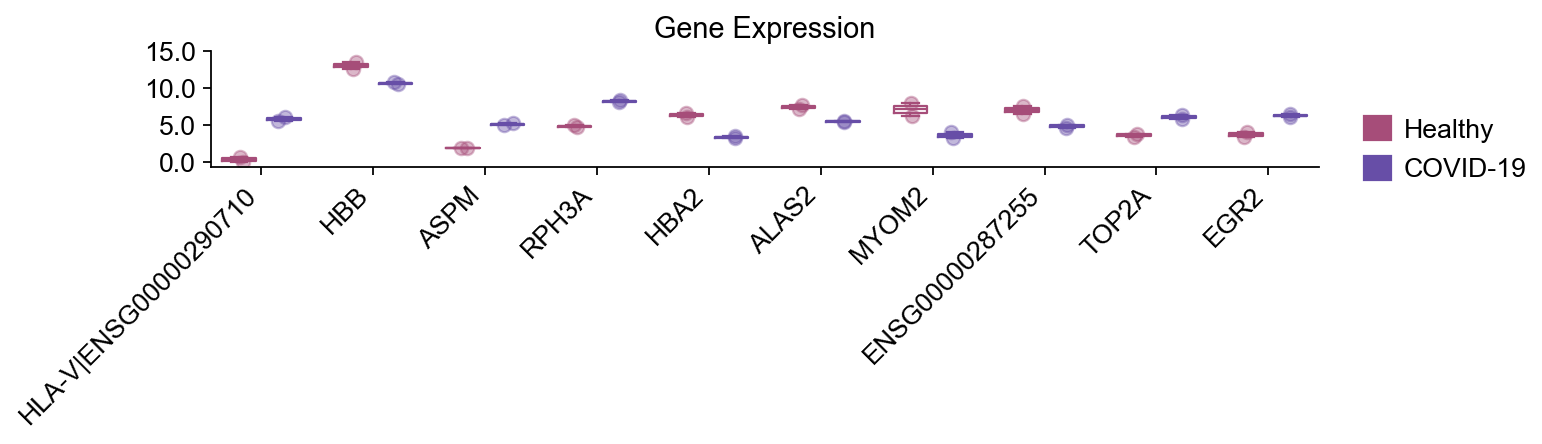

In [14]:

dds.plot_volcano(title='DEG Analysis',figsize=(5,5),
                 plot_genes_num=8,plot_genes_fontsize=12,)

dds.plot_boxplot(genes= gene_list, 
   treatment_groups=disease_groups,
   treatment_name='COVID-19',control_name='Healthy',
                control_groups=healthy_groups,figsize=(10,3),fontsize=12,
                 legend_bbox=(1.2,0.55))

plt.xticks(rotation=45, ha="right")  
plt.tight_layout()


## 16) Additional boxplot examples

A compact example showing how to manually specify a gene list from another upstream analysis step for plotting.



(<Figure size 160x240 with 1 Axes>,
 <Axes: title={'center': 'Gene Expression'}>)

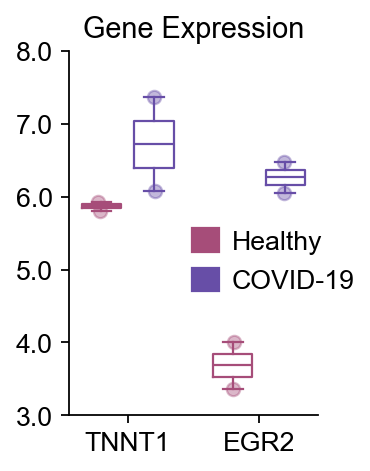

In [18]:
dds.plot_boxplot(genes=['TNNT1','EGR2'], 
   treatment_groups=disease_groups,
   treatment_name='COVID-19',control_name='Healthy',
                control_groups=healthy_groups,figsize=(2,3),fontsize=12,
                 legend_bbox=(1.2,0.55))

---

## Next steps (optional)

From this point, typical downstream bulk RNA-seq analyses include:
- Functional enrichment (e.g., GO / KEGG / Reactome) on up/down DEGs  
- Protein–protein interaction (PPI) network construction and visualization  
- Pathway-level scoring and reporting

You can extend this notebook by adding those sections once DEGs are finalized for your study.

